## Overview
This worksheet demonstrates the concept of the Z-test, P-value, and their application in hypothesis testing. It simulates a population, a new teaching method, and then performs a Z-test to evaluate the statistical significance of the new method's results. Additionally, it visualizes the sampling distribution of sample means and explores the critical impact of sample size on the calculated P-value.

In [9]:
import numpy as np
import scipy.stats as stats

# Define population parameters and sample statistics
mu = 70  # Population mean
sigma = 10  # Population standard deviation
n = 50  # Sample size
sample_mean = 74  # Observed sample mean

# Calculate the Z-score
# Z = (sample_mean - population_mean) / (population_std / sqrt(sample_size))
Z = (sample_mean - mu) / (sigma / np.sqrt(n))

# Calculate the two-tailed P-value
# The P-value is 2 times the probability of observing a Z-score as extreme as, or more extreme than, the calculated Z-score.
P_value = 2 * (1 - stats.norm.cdf(abs(Z)))

# Print the results
print("Z-score:", Z)
print("P-value:", P_value)


Z-score: 2.8284271247461903
P-value: 0.004677734981047177


True Population Mean: 70.0096686814095

Sample Mean (New Method): 71.60377114434759
Z-score: 1.1340374516394902
P-value: 0.25677883859756756
Decision: Fail to reject H0 (New method is not statistically significant)


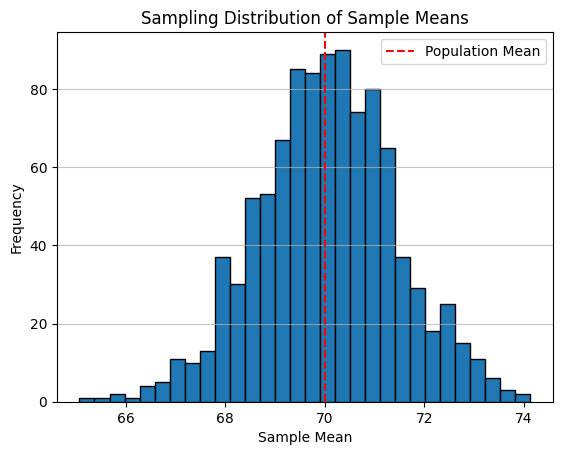

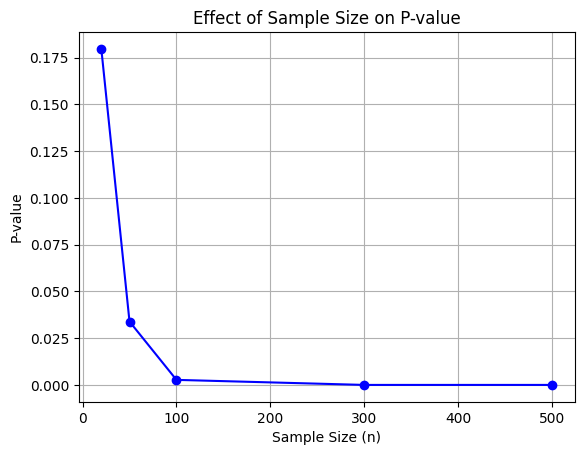


Sample Size vs P-value:
n = 20, p-value = 1.79712e-01
n = 50, p-value = 3.38949e-02
n = 100, p-value = 2.69980e-03
n = 300, p-value = 2.03455e-07
n = 500, p-value = 1.97034e-11


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# -----------------------------
# Step 1: Simulate Population
# -----------------------------

# Set a random seed for reproducibility
np.random.seed(42)

# Define true population parameters
population_mean = 70
population_std = 10

# Generate a large synthetic population based on a normal distribution
population = np.random.normal(
    loc=population_mean,
    scale=population_std,
    size=100000
)

# Verify the mean of the simulated population
print("True Population Mean:", np.mean(population))


# ----------------------------------------
# Step 2: Simulate New Teaching Method
# ----------------------------------------

# Define sample size and assumed improved mean for the new method
n = 50
true_improved_mean = 73   # Assume new method improves the mean by +3 points

# Generate a sample from the 'new method' population
sample = np.random.normal(
    loc=true_improved_mean,
    scale=population_std,
    size=n
)

# Calculate the mean of the simulated sample
sample_mean = np.mean(sample)

print("\nSample Mean (New Method):", sample_mean)


# -----------------------------
# Step 3: Perform Z-Test
# -----------------------------

# Calculate the Z-score for the sample mean against the original population mean
# Z = (sample_mean - population_mean) / (population_std / sqrt(sample_size))
z = (sample_mean - population_mean) / (population_std / np.sqrt(n))

# Calculate the two-tailed P-value
# The P-value is 2 times the probability of observing a Z-score as extreme as, or more extreme than, the calculated Z-score.
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print("Z-score:", z)
print("P-value:", p_value)

# Make a decision based on the P-value and a significance level of 0.05
if p_value < 0.05:
    print("Decision: Reject H0 (New method is statistically significant)")
else:
    print("Decision: Fail to reject H0 (New method is not statistically significant)")


# ---------------------------------------------
# Step 4: Visualize Sampling Distribution
# ---------------------------------------------

# Simulate the sampling distribution of the sample means under the null hypothesis (no improvement)
sample_means = []

for _ in range(1000): # Perform 1000 simulations
    # Draw a sample from the original population and calculate its mean
    s = np.random.normal(population_mean, population_std, n)
    sample_means.append(np.mean(s))

# Plot the histogram of the simulated sample means
plt.figure()
plt.hist(sample_means, bins=30, edgecolor='black') # Add edge color for better visualization
plt.axvline(population_mean, color='red', linestyle='dashed', linewidth=1.5, label='Population Mean') # Mark the population mean
plt.title("Sampling Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend() # Show legend for axvline
plt.grid(axis='y', alpha=0.75) # Add a grid for readability
plt.show()


# ---------------------------------------
# Step 5: Effect of Sample Size
# ---------------------------------------

# Define different sample sizes to observe their effect on the P-value
sample_sizes = [20, 50, 100, 300, 500]
p_values = []

# Calculate P-values for each sample size, assuming the same true improved mean
for size in sample_sizes:
    # Calculate Z-score for the current sample size
    z_s = (true_improved_mean - population_mean) / (population_std / np.sqrt(size))
    # Calculate two-tailed P-value
    p_s = 2 * (1 - stats.norm.cdf(abs(z_s)))
    p_values.append(p_s)

# Plot the relationship between sample size and P-value
plt.figure()
plt.plot(sample_sizes, p_values, marker='o', linestyle='-', color='blue') # Add markers and line style
plt.title("Effect of Sample Size on P-value")
plt.xlabel("Sample Size (n)")
plt.ylabel("P-value")
plt.grid(True) # Add grid
plt.show()

print("\nSample Size vs P-value:")
for size, p in zip(sample_sizes, p_values):
    print(f"n = {size}, p-value = {p:.5e}") # Format p-value for better readability


## Summary of Evaluation

**Initial Z-Test:** A Z-test with a sample mean of 74 (vs. population mean 70, sigma 10, n=50) resulted in a Z-score of `2.83` and a P-value of `0.0047`. This indicates a statistically significant difference from the population mean.

**Simulated New Teaching Method:** For a simulated new teaching method (assuming a true improved mean of 73 with n=50), the observed sample mean was `71.60`. The Z-test for this sample yielded a Z-score of `1.13` and a P-value of `0.2568`. At a 0.05 significance level, we **fail to reject the null hypothesis**, meaning the observed improvement was not statistically significant in this particular simulation.

**Effect of Sample Size:** The analysis clearly showed that increasing the sample size dramatically decreases the P-value, making it easier to detect a statistically significant effect if one truly exists. For an assumed true improved mean of 73:
-   n = 20, p-value = 1.797e-01
-   n = 50, p-value = 3.389e-02 (becomes significant at \alpha = 0.05)
-   n = 100, p-value = 2.700e-03
-   n = 300, p-value = 2.035e-07
-   n = 500, p-value = 1.970e-11

This highlights the importance of sample size in statistical power and the ability to find significant results.